# House Price Prediction — Test Dataset Pipeline

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Load Train & Test Data

In [2]:
# Update these paths to your local file locations
train_path = r"C:\Users\Prem\Desktop\mayank\house price prediction\train.csv"
test_path  = r"C:\Users\Prem\Desktop\mayank\house price prediction\test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
test_df.head()

Train shape: (29451, 12)
Test shape : (68720, 11)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
0,Owner,0,0,1,BHK,545.171340,1,1,"Kamrej,Surat",21.262000,73.047700
1,Dealer,1,1,2,BHK,800.000000,0,0,"Panvel,Lalitpur",18.966114,73.148278
2,Dealer,0,0,2,BHK,1257.096513,1,1,"New Town,Kolkata",22.592200,88.484911
3,Dealer,0,0,3,BHK,1400.329489,1,1,"Kalwar Road,Jaipur",26.988300,75.584600
4,Owner,0,0,1,BHK,430.477830,1,1,"Mai Mandir,Nadiad",22.700000,72.870000


## 3. Preprocessing Function

We define a single reusable function so train and test go through **identical** steps.

In [3]:
TIER1_CITIES = [
    'Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata',
    'Hyderabad', 'Pune', 'Ahmedabad'
]
TIER2_CITIES = [
    'Jaipur', 'Lucknow', 'Kanpur', 'Nagpur', 'Indore', 'Bhopal',
    'Visakhapatnam', 'Vadodara', 'Coimbatore', 'Guwahati',
    'Chandigarh', 'Patna', 'Raipur', 'Ranchi', 'Surat',
    'Mysore', 'Jodhpur', 'Agra', 'Varanasi', 'Allahabad',
    'Dehradun', 'Udaipur', 'Gwalior', 'Jalandhar', 'Amritsar',
    'Ludhiana', 'Meerut', 'Rajkot', 'Kolhapur', 'Madurai',
    'Tirupati', 'Vijayawada', 'Warangal', 'Salem', 'Hubli',
    'Dharwad', 'Belgaum', 'Mangalore', 'Thrissur', 'Kochi', 'Ernakulam'
]

def preprocess(df, is_train=True):
    df = df.copy()

    # ── Strip whitespace from string columns ──────────────────────────
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

    # ── Outlier removal (train only) ──────────────────────────────────
    # Rows with unrealistic square footage or price are data errors
    if is_train:
        df = df[df['SQUARE_FT'] < 1_000_000]          # > 1M sq ft is an error
        df = df[df['TARGET(PRICE_IN_LACS)'] < 7_000]  # ₹7,000L+ are outliers
        df = df[df['SQUARE_FT'] > 0]

    # ── Feature: log-transform SQUARE_FT (reduces skew) ──────────────
    df['LOG_SQFT'] = np.log1p(df['SQUARE_FT'])

    # ── Feature: price per sqft (only possible on train) ─────────────
    # (not added here — would leak target into features)

    # ── Feature: extract CITY from ADDRESS ───────────────────────────
    df['CITY'] = df['ADDRESS'].str.rsplit(',', n=1).str[-1].str.strip()

    # ── Feature: CITY tier classification ────────────────────────────
    def tier(city):
        if city in TIER1_CITIES: return 'Tier 1'
        if city in TIER2_CITIES: return 'Tier 2'
        return 'Tier 3'
    df['CITY_CAT'] = df['CITY'].apply(tier)

    # ── One-hot encode categorical columns ───────────────────────────
    df = pd.get_dummies(df, columns=['BHK_OR_RK', 'POSTED_BY', 'CITY_CAT'], dtype=int)

    # ── Drop columns not used for modelling ──────────────────────────
    drop_cols = ['ADDRESS', 'CITY', 'SQUARE_FT']  # replaced by LOG_SQFT
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    return df

print("Preprocessing function defined.")

Preprocessing function defined.


## 4. Preprocess Train & Test

In [4]:
train_clean = preprocess(train_df, is_train=True)
test_clean  = preprocess(test_df,  is_train=False)

# ── Align columns: test must have same columns as train (minus target) ──
target_col = 'TARGET(PRICE_IN_LACS)'

train_features = [c for c in train_clean.columns if c != target_col]
test_clean = test_clean.reindex(columns=train_features, fill_value=0)

print("Train features:", train_clean.shape)
print("Test  features:", test_clean.shape)
print("\nFeature columns:")
print(train_features)

Train features: (29328, 17)
Test  features: (68720, 16)

Feature columns:
['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'LOG_SQFT', 'BHK_OR_RK_BHK', 'BHK_OR_RK_RK', 'POSTED_BY_Builder', 'POSTED_BY_Dealer', 'POSTED_BY_Owner', 'CITY_CAT_Tier 1', 'CITY_CAT_Tier 2', 'CITY_CAT_Tier 3']


## 5. Check for Nulls After Preprocessing

In [5]:
print("=== Train nulls ===")
print(train_clean.isnull().sum()[train_clean.isnull().sum() > 0])

print("\n=== Test nulls ===")
print(test_clean.isnull().sum()[test_clean.isnull().sum() > 0])

# Fill any remaining nulls with column median
for col in test_clean.columns:
    if test_clean[col].isnull().any():
        test_clean[col].fillna(train_clean[col].median(), inplace=True)

print("\nNull check complete — all filled.")

=== Train nulls ===
Series([], dtype: int64)

=== Test nulls ===
Series([], dtype: int64)

Null check complete — all filled.


## 6. Train / Validation Split

In [6]:
X = train_clean[train_features]
y = train_clean[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")

X_train: (23462, 16)  |  X_val: (5866, 16)


## 7. Train Models & Evaluate on Validation Set

In [7]:
def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    mae   = mean_absolute_error(y_v, preds)
    rmse  = mean_squared_error(y_v, preds)
    r2    = r2_score(y_v, preds)
    print(f"{name:35s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  R²={r2:.4f}")
    return model, preds

print(f"{'Model':<35}  {'MAE':>10}  {'RMSE':>10}  R²")
print("-" * 65)

ridge_model, _  = evaluate("Ridge Regression",Ridge(alpha=10),X_train, y_train, X_val, y_val)
rf_model,    _  = evaluate("Random Forest",RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), X_train, y_train, X_val, y_val)
gb_model,    _  = evaluate("Gradient Boosting",GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42), X_train, y_train, X_val, y_val)

Model                                       MAE        RMSE  R²
-----------------------------------------------------------------
Ridge Regression                     MAE=   78.39  RMSE=39616.24  R²=0.1849
Random Forest                        MAE=   26.31  RMSE= 9970.97  R²=0.7949
Gradient Boosting                    MAE=   29.82  RMSE=10096.92  R²=0.7923


## 8. Feature Importance (from best model)

In [8]:
# Use Random Forest for feature importance (replace with gb_model if that performs better)
best_model = rf_model

importances = pd.Series(best_model.feature_importances_, index=train_features)
print("Top 10 most important features:")
print(importances.sort_values(ascending=False).head(10).to_string())

Top 10 most important features:
LOG_SQFT            0.529608
LATITUDE            0.146575
RESALE              0.128832
LONGITUDE           0.110029
BHK_NO.             0.041796
POSTED_BY_Dealer    0.010487
CITY_CAT_Tier 2     0.008034
RERA                0.007068
CITY_CAT_Tier 1     0.006124
CITY_CAT_Tier 3     0.004433


## 9. Predict on Test Dataset

In [9]:
# Retrain best model on full training data before predicting
best_model.fit(X, y)

test_predictions = best_model.predict(test_clean)

# Clip negatives (prices can't be negative)
test_predictions = np.clip(test_predictions, 0, None)

print(f"Predictions generated: {len(test_predictions)} rows")
print(f"Min  : ₹{test_predictions.min():.2f}L")
print(f"Max  : ₹{test_predictions.max():.2f}L")
print(f"Mean : ₹{test_predictions.mean():.2f}L")
print(f"Median: ₹{np.median(test_predictions):.2f}L")

Predictions generated: 68720 rows
Min  : ₹4.88L
Max  : ₹6466.80L
Mean : ₹125.55L
Median: ₹64.07L


## 10. Sanity Check — Distribution of Predictions vs Train Target

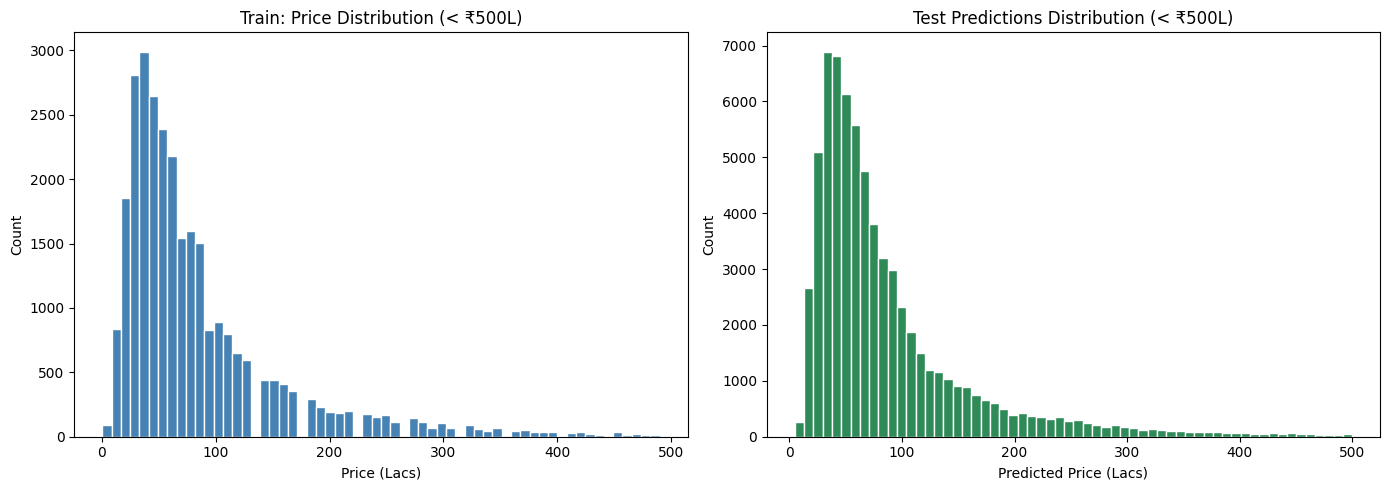

If both distributions look similar, the model is generalising well.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution (after outlier removal)
axes[0].hist(y[y < 500], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Train: Price Distribution (< ₹500L)')
axes[0].set_xlabel('Price (Lacs)')
axes[0].set_ylabel('Count')

# Test predictions distribution
axes[1].hist(test_predictions[test_predictions < 500], bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Test Predictions Distribution (< ₹500L)')
axes[1].set_xlabel('Predicted Price (Lacs)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


both distributions look similar,Hence the model is generalising well.